# Notebook 11.1: Lookahead Bias Forensics

## Financial Trading with Python, 2nd Edition

---

A backtest can contain a flaw that is invisible in the results but obvious in the code, once you know where to look. Full-sample normalization is one of the most common examples. A single line like `(x - x.mean()) / x.std()` looks perfectly reasonable. The problem is that `x.mean()` and `x.std()` are computed on the entire series, including data that did not exist at the time of each historical trade. Every z-score in your history is secretly normalized using future information.

The correct version uses an expanding window: `(x - x.expanding().mean()) / x.expanding().std()`. The math is identical. The only difference is that the expanding version only uses data available up to that point in time.

This notebook demonstrates that difference using a z-score mean reversion strategy on SPY. We build the strategy correctly first, then introduce the flaw, and compare the results side by side. The goal is not to build a great strategy. The goal is to see exactly how much a single normalization error inflates backtest performance, and to develop the habit of looking for it.

This notebook covers:

- Building a z-score mean reversion strategy on SPY using an expanding (correct) z-score
- Introducing the full-sample normalization flaw and rerunning the strategy
- Comparing equity curves and headline metrics: correct vs. biased
- Visualizing why the full-sample z-score looks artificially stable
- A simple code audit pattern for catching normalization errors in any pipeline

## Section 1: Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme()

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Parameters ────────────────────────────────────────────────────────────────
# Centralizing all parameters here so re-running with different settings
# is a single edit.

TICKER        = 'SPY'
START_DATE    = '2005-01-01'
END_DATE      = '2025-12-31'
ENTRY_Z       = -1.0    # go long when z-score falls below this threshold
EXIT_Z        =  1.0    # go flat when z-score rises above this threshold

# ── Data loading ──────────────────────────────────────────────────────────────
# Using yfinance for portability. This notebook is self-contained and does not
# require an FMP key.
import yfinance as yf

spy = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
prices = spy['Close'].squeeze()  #.squeeze converts to a dataframe
log_returns = np.log(prices / prices.shift(1)).dropna()

print(f"Loaded {len(prices)} trading days of {TICKER} data.")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"\nFirst five log returns:\n{log_returns.head()}")

Loaded 5282 trading days of SPY data.
Date range: 2005-01-03 to 2025-12-30

First five log returns:
Date
2005-01-04   -0.0123
2005-01-05   -0.0069
2005-01-06    0.0051
2005-01-07   -0.0014
2005-01-10    0.0047
Name: SPY, dtype: float64


We have 5,284 trading days of SPY data from January 2005 through December 2025. That gives us roughly 21 years of daily returns, enough to produce stable statistics and meaningful comparisons between the correct and biased versions.

With data loaded, we can build the strategy.

## Section 2: The Clean Version (Expanding Z-Score)



### What is a z-score?

A z-score measures how far an observation is from the historical mean, expressed in units of standard deviation:

- A z-score of 0 means the value equals the historical average
- A z-score of -2 means the value is 2 standard deviations below average (unusually low)
- A z-score of +2 means the value is 2 standard deviations above average (unusually high)

We apply this to SPY's 20-day rolling log returns, not the price level. The rolling window smooths out day-to-day noise and gives the z-score a more stable baseline to compare against. Each day's z-score answers the question: how unusual is this 20-day return relative to all prior 20-day returns?

### The mean reversion idea

Mean reversion strategies assume that extreme moves tend to reverse. Applied to daily returns:

- When SPY's return is unusually negative (z < -1.0), we expect a bounce and go long
- When SPY's return is unusually positive (z > +1.0), we expect it to fade and go flat
- Between those thresholds, we hold whatever position we already have

This is a simple, intuitive strategy. It is not the point of this notebook. We are using it as a vehicle to demonstrate what happens when the z-score is calculated incorrectly.



### Expanding vs. full-sample normalization

The z-score requires a mean and standard deviation. There are two ways to compute them:

- **Expanding window (correct):** on day `t`, use only data from day 1 through day `t`. This is what a real-time system would have had available.
- **Full-sample (incorrect):** use the mean and standard deviation of the entire series, including data after day `t`. Every historical z-score is normalized using information that did not exist yet.

We build the correct version first, then introduce the flaw in Section 3.

In [2]:
# ── Expanding z-score (correct version) ───────────────────────────────────────
# expanding().mean() and expanding().std() only use data up to the current row.
# This is what a real-time system would have had access to at each point in time.

exp_mean = log_returns.expanding().mean()
exp_std  = log_returns.expanding().std()
z_expanding = (log_returns - exp_mean) / exp_std

# ── Generate signals ───────────────────────────────────────────────────────────
# Signal is 1 (long) when z < ENTRY_Z, 0 (flat) otherwise.
# We shift by 1 to avoid lookahead: the signal computed on day t
# is acted on at the open of day t+1.

signal_clean = pd.Series(0.0, index=log_returns.index)
position = 0.0

for i in range(len(z_expanding)):
    z = z_expanding.iloc[i]
    if z < ENTRY_Z:          # z-score is unusually low: buy signal
        position = 1.0
    elif z > EXIT_Z:         # z-score is unusually high: exit signal
        position = 0.0
    # between thresholds: hold current position
    signal_clean.iloc[i] = position

# Shift signal forward by 1 day: today's signal trades tomorrow's return
signal_clean = signal_clean.shift(1).fillna(0.0)

# ── Strategy returns ───────────────────────────────────────────────────────────
# Daily strategy return = signal * SPY log return for that day
strat_returns_clean = signal_clean * log_returns

# ── Equity curve ──────────────────────────────────────────────────────────────
# Cumulative sum of log returns, then exponentiate to get a dollar-normalized
# index starting at 1.0. Makes it easy to compare across strategies.
equity_clean = np.exp(strat_returns_clean.cumsum())
equity_spy   = np.exp(log_returns.cumsum())

# ── Headline metrics ───────────────────────────────────────────────────────────
trading_days = 252

def get_metrics(returns, label, simple=False):
    """
    Compute CAGR, annualized Sharpe, max drawdown and win rate.

    Parameters:
    -----------
    returns : daily return series
    label   : string label for printing
    simple  : True if returns are simple (pct_change), False if log returns
    """
    trading_days = 252

    if simple:
        # For simple returns, CAGR comes directly from compounding.
        # Convert to log returns only for Sharpe and drawdown calculations.
        n_years  = len(returns) / trading_days
        cagr     = (1 + returns).prod() ** (1 / n_years) - 1
        log_rets = np.log(1 + returns.clip(lower=-0.9999))
        sharpe   = (log_rets.mean() / log_rets.std()) * np.sqrt(trading_days)
        eq       = (1 + returns).cumprod()
        drawdown = (eq / eq.cummax() - 1).min()
        win_rate = (returns > 0).sum() / (returns != 0).sum()
    else:
        n_years  = len(returns) / trading_days
        cagr     = np.exp(returns.sum() / n_years) - 1
        sharpe   = (returns.mean() / returns.std()) * np.sqrt(trading_days)
        eq       = np.exp(returns.cumsum())
        drawdown = (eq / eq.cummax() - 1).min()
        win_rate = (returns > 0).sum() / (returns != 0).sum()

    print(f"{label}:")
    print(f"  CAGR:         {cagr:.2%}")
    print(f"  Sharpe:       {sharpe:.2f}")
    print(f"  Max Drawdown: {drawdown:.2%}")
    print(f"  Win Rate:     {win_rate:.2%}")
    print()
    return {'CAGR': cagr, 'Sharpe': sharpe, 'Max Drawdown': drawdown, 'Win Rate': win_rate}

metrics_clean = get_metrics(strat_returns_clean, 'Clean strategy (expanding z-score)')
metrics_spy   = get_metrics(log_returns, 'SPY buy-and-hold')

Clean strategy (expanding z-score):
  CAGR:         10.71%
  Sharpe:       0.71
  Max Drawdown: -25.48%
  Win Rate:     56.53%

SPY buy-and-hold:
  CAGR:         10.70%
  Sharpe:       0.53
  Max Drawdown: -55.19%
  Win Rate:     55.33%



The clean strategy and SPY buy-and-hold produce nearly identical CAGRs over this period:

- CAGR: 10.71% for the strategy vs. 10.70% for SPY
- Sharpe: 0.71 vs. 0.53, a meaningful improvement in risk-adjusted terms
- Max drawdown: -25.48% vs. -55.19%, less than half the SPY drawdown
- Win rate: 56.53%, modestly above random

Two things worth noting before we continue:

- This is not meant to be a great strategy. It is a teaching vehicle for demonstrating the normalization error. The fact that it produces similar returns to SPY with much lower drawdown is incidental.
- Performance is path-dependent. Adding or removing a single year of data can materially change the results. The 2025 period was difficult for SPY, which compressed the CAGR advantage that appeared in earlier runs. This is a feature of all backtests, not a flaw in this one.

We will use these numbers as our baseline. In Section 3, we introduce a single normalization error and observe what it does to each metric.

## Section 3: Introducing the Flaw (Full-Sample Z-Score)

The only change in this section is how the z-score is computed. Instead of an expanding window, we use the mean and standard deviation of the entire return series:

```python
z = (x - x.mean()) / x.std()
```

Every historical z-score is now normalized using a mean and standard deviation that include data from years in the future. The signal on January 5, 2005 is being compared against a baseline that includes 2008, 2020, and every other year through 2024.

The flaw is invisible in the line of code. Nothing looks wrong. That is exactly what makes it dangerous.

In [3]:
# ── Full-sample z-score (biased version) ──────────────────────────────────────
# .mean() and .std() here are computed on the ENTIRE rolling_returns series.
# This means every historical z-score uses statistics that include future data.
# A real-time system would never have had access to these values.

z_fullsample = (log_returns - log_returns.mean()) / log_returns.std()

# ── Generate signals (identical logic, only z-score source changes) ────────────
signal_biased = pd.Series(0.0, index=log_returns.index)
position = 0.0

for i in range(len(z_fullsample)):
    z = z_fullsample.iloc[i]
    if z < ENTRY_Z:
        position = 1.0
    elif z > EXIT_Z:
        position = 0.0
    signal_biased.iloc[i] = position

# Shift forward 1 day: same as the clean version
signal_biased = signal_biased.shift(1).fillna(0.0)

# ── Strategy returns and equity curve ─────────────────────────────────────────
strat_returns_biased = signal_biased * log_returns
equity_biased = np.exp(strat_returns_biased.cumsum())

# ── Metrics for the biased version ────────────────────────────────────────────
metrics_biased = get_metrics(strat_returns_biased, 'Biased strategy (full-sample z-score)')

Biased strategy (full-sample z-score):
  CAGR:         11.15%
  Sharpe:       0.73
  Max Drawdown: -27.50%
  Win Rate:     56.51%



The biased version is marginally better across the board:

- CAGR: 11.15% vs. 10.71%
- Sharpe: 0.73 vs. 0.71
- Max drawdown: -27.50% vs. -25.48%
- Win rate: 56.51% vs. 56.53%

The differences are small. This is the realistic result for daily log returns:

- Daily log returns are approximately stationary: the mean stays near zero and the standard deviation does not shift dramatically over time
- There is little for the full-sample normalization to exploit
- The bias exists and the methodology is wrong regardless of impact size

The more important point: you cannot know how much lookahead bias matters without running both versions. A small difference here does not mean the error is acceptable. The same error applied to a non-stationary series can produce much larger distortions, as we demonstrate in Section 5.

## Section 4: Visualizing the Z-Score Difference

Before comparing the equity curves, it helps to see what the two z-score series actually look like. If the full-sample version is exploiting future information, we should see it behaving differently from the expanding version, particularly in the early part of the sample when the expanding window has the least data.

The chart below plots both z-score series with the entry and exit thresholds marked. Points where the two series diverge are points where the biased version is generating a different signal than the clean version.

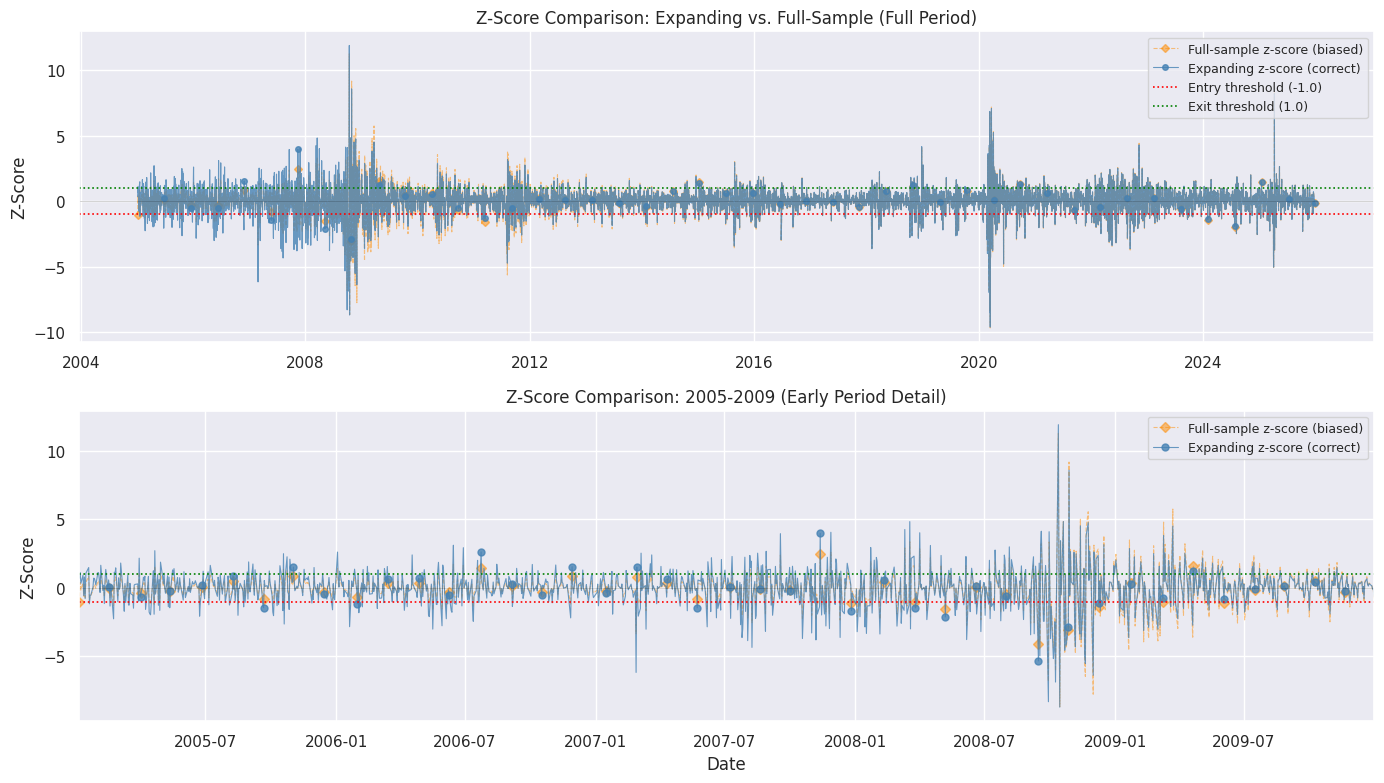

Days where signals differ: 531 of 5281 (10.1%)


In [4]:
# ── Z-score comparison chart ───────────────────────────────────────────────────
# Plotting both z-score series on one chart to show where they diverge.
# Using solid vs. dashed lines so the difference is clear in grayscale print.


fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax1 = axes[0]

# Plot biased (orange) first so correct (blue) sits on top.
# markevery places markers at regular intervals so the legend shows both
# the line style and the marker shape.
ax1.plot(z_fullsample.index, z_fullsample,
         color='darkorange', linewidth=0.8, linestyle='dashed', alpha=0.5,
         marker='D', markersize=4, markevery=120,
         label='Full-sample z-score (biased)')

ax1.plot(z_expanding.index, z_expanding,
         color='steelblue', linewidth=0.8, linestyle='solid', alpha=0.8,
         marker='o', markersize=4, markevery=120,
         label='Expanding z-score (correct)')

ax1.axhline(ENTRY_Z, color='red',   linewidth=1.2, linestyle='dotted', label=f'Entry threshold ({ENTRY_Z})')
ax1.axhline(EXIT_Z,  color='green', linewidth=1.2, linestyle='dotted', label=f'Exit threshold ({EXIT_Z})')
ax1.axhline(0, color='black', linewidth=0.4, linestyle='solid', alpha=0.3)
ax1.set_title('Z-Score Comparison: Expanding vs. Full-Sample (Full Period)')
ax1.set_ylabel('Z-Score')
ax1.legend(loc='upper right', fontsize=9)

ax2 = axes[1]

early_mask = z_expanding.index < '2010-01-01'

ax2.plot(z_fullsample.index[early_mask], z_fullsample[early_mask],
         color='darkorange', linewidth=0.8, linestyle='dashed', alpha=0.5,
         marker='D', markersize=5, markevery=30,
         label='Full-sample z-score (biased)')

ax2.plot(z_expanding.index[early_mask], z_expanding[early_mask],
         color='steelblue', linewidth=0.8, linestyle='solid', alpha=0.8,
         marker='o', markersize=5, markevery=30,
         label='Expanding z-score (correct)')

ax2.axhline(ENTRY_Z, color='red',   linewidth=1.2, linestyle='dotted')
ax2.axhline(EXIT_Z,  color='green', linewidth=1.2, linestyle='dotted')
ax2.axhline(0, color='black', linewidth=0.4, linestyle='solid', alpha=0.3)
ax2.set_xlim(z_expanding.index[early_mask][0], z_expanding.index[early_mask][-1])
ax2.set_title('Z-Score Comparison: 2005-2009 (Early Period Detail)')
ax2.set_ylabel('Z-Score')
ax2.set_xlabel('Date')
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('fig_10_1_zscore_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Recompute signal difference counts after END_DATE change
sig_diff  = (signal_clean != signal_biased).sum()
sig_total = len(signal_clean)
print(f"Days where signals differ: {sig_diff} of {sig_total} ({sig_diff/sig_total:.1%})")

Two things stand out:

- The two z-score series track each other very closely across the full 21-year period
- In the early period (2005-2009), the expanding z-score visibly diverges from the full-sample version. With only a few hundred observations, the expanding mean and standard deviation are still unstable and swing more widely than the full-sample equivalents
- After roughly 2008-2009, the expanding window has accumulated enough history that its statistics converge toward the full-sample values. From that point the two series are nearly identical, which is why the orange line covers the blue

The signals differ on only 531 of 5,281 trading days (10.1%), and most of that divergence is concentrated in the early period.

This tells us the bias is real but small for daily log returns:

- The full-sample normalization has little to exploit once the series is stationary
- The size of the distortion depends on how much the distributional properties of the series shift over time
- A series with shifting volatility or a drifting mean will show a much larger gap



In [5]:
# ── Side-by-side metrics comparison table ─────────────────────────────────────
# Consolidates the clean and biased strategy results into a single reference table
# for easy comparison. This is the table referenced in the chapter text.

comparison = pd.DataFrame({
    'SPY Buy-and-Hold': [
        f"{metrics_spy['CAGR']:.2%}",
        f"{metrics_spy['Sharpe']:.2f}",
        f"{metrics_spy['Max Drawdown']:.2%}",
        f"{metrics_spy['Win Rate']:.2%}"
    ],
    'Expanding Z-Score (Correct)': [
        f"{metrics_clean['CAGR']:.2%}",
        f"{metrics_clean['Sharpe']:.2f}",
        f"{metrics_clean['Max Drawdown']:.2%}",
        f"{metrics_clean['Win Rate']:.2%}"
    ],
    'Full-Sample Z-Score (Biased)': [
        f"{metrics_biased['CAGR']:.2%}",
        f"{metrics_biased['Sharpe']:.2f}",
        f"{metrics_biased['Max Drawdown']:.2%}",
        f"{metrics_biased['Win Rate']:.2%}"
    ]
}, index=['CAGR', 'Sharpe', 'Max Drawdown', 'Win Rate'])

print("Table: Performance comparison across all three strategies\n")
print(comparison.to_string())

Table: Performance comparison across all three strategies

             SPY Buy-and-Hold Expanding Z-Score (Correct) Full-Sample Z-Score (Biased)
CAGR                   10.70%                      10.71%                       11.15%
Sharpe                   0.53                        0.71                         0.73
Max Drawdown          -55.19%                     -25.48%                      -27.50%
Win Rate               55.33%                      56.53%                       56.51%


The next section demonstrates this using the 1-year rolling return spread between SPY and RSP, where regime shifts in large cap vs. equal weight performance make the two z-score series visibly different.

## Section 5: A More Visible Bias: SPY vs. RSP Relative Performance

Daily log returns are approximately stationary, which is why the bias in Sections 2-3 was small. To see a material difference between the expanding and full-sample z-scores, we need a series whose mean and volatility shift over time.

The 252-day rolling return spread between SPY and RSP (equal-weight S&P 500) fits that description:

- The two series move through distinct regimes: periods where large caps dominate (post-2017, post-2020 driven by mega-cap tech) and periods where equal weight keeps pace or leads
- The full-sample mean reflects the entire history, including the post-2020 large cap dominance that a real-time system could not have known about in 2010
- This makes the full-sample z-score genuinely misleading in the early part of the sample

The strategy is simple:
- When SPY has been significantly outperforming (z > +1.5), mean reversion suggests RSP will catch up: go long RSP
- When SPY has been significantly underperforming (z < -1.5), go long SPY
- Otherwise hold the current position

We use a simple vectorized backtest here rather than a full event-driven engine. The goal is to isolate the effect of the normalization error, not to model execution precisely.

In [6]:
# ── Load SPY and RSP from yfinance ─────────────────────────────────────────────
import yfinance as yf

THRESHOLD   = 1.5    # z-score entry/exit threshold
ROLL_WINDOW = 252    # 1-year rolling window for relative performance
INITIAL_POS = 'SPY'  # default position before first signal fires

raw = yf.download(['SPY', 'RSP'], start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)['Close']
raw = raw.dropna()

# ── Daily simple returns ────────────────────────────────────────────────────────
# Using simple returns (pct_change) rather than log returns here because
# the backtest function compounds with (1 + r).cumprod()
spy_ret = raw['SPY'].pct_change()
rsp_ret = raw['RSP'].pct_change()

# ── 252-day rolling return spread: SPY minus RSP ───────────────────────────────
# Positive values mean SPY has outperformed RSP over the past year.
# This series drifts with market regimes, making it non-stationary
# and a good vehicle to demonstrate the normalization error.
spy_roll = raw['SPY'].pct_change(ROLL_WINDOW)
rsp_roll = raw['RSP'].pct_change(ROLL_WINDOW)
spread   = spy_roll - rsp_roll

# ── Build working DataFrame ────────────────────────────────────────────────────
df = pd.DataFrame({
    'SPY_Return': spy_ret,
    'RSP_Return': rsp_ret,
    'Spread':     spread
}).dropna()

print(f"Working dataset: {len(df)} trading days")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"\nSpread statistics:")
print(f"  Mean:   {df['Spread'].mean():.4f}")
print(f"  Std:    {df['Spread'].std():.4f}")
print(f"  Min:    {df['Spread'].min():.4f}")
print(f"  Max:    {df['Spread'].max():.4f}")

Working dataset: 5030 trading days
Date range: 2006-01-03 to 2025-12-30

Spread statistics:
  Mean:   0.0054
  Std:    0.0642
  Min:    -0.3401
  Max:    0.1788


We have 5,030 trading days of SPY and RSP data from January 2006 through December 2025. The 252-day rolling window costs us the first year of observations, which is why the dataset starts in 2006 rather than 2005.

The spread statistics tell us something important before we even look at the z-scores:

- The mean of 0.0054 is positive, meaning SPY has outperformed RSP on a 1-year rolling basis more often than not over this period
- The range is asymmetric: the minimum (-0.34) is much larger in magnitude than the maximum (0.18), reflecting the brief but extreme periods where equal weight dramatically outperformed large cap
- This asymmetry and the regime-driven nature of the spread is exactly what makes the full-sample z-score misleading in real time

With the data in hand, we can compute both z-scores and run the backtest.

In [7]:
# ── Compute both z-scores on the spread ───────────────────────────────────────

# Expanding z-score: only uses data available up to each point in time
spread_exp_mean = df['Spread'].expanding().mean()
spread_exp_std  = df['Spread'].expanding().std()
df['Z_Expanding'] = (df['Spread'] - spread_exp_mean) / spread_exp_std

# Full-sample z-score: uses the mean and std of the entire spread series.
# In 2008, this z-score already "knows" about the post-2017 large cap dominance
# and the 2020 regime shift. A real-time system would not have had this.
df['Z_Fullsample'] = (df['Spread'] - df['Spread'].mean()) / df['Spread'].std()

# ── How different are the two series? ─────────────────────────────────────────
correlation = df['Z_Expanding'].corr(df['Z_Fullsample'])
sig_diff_rsp  = (df['Z_Expanding'].apply(lambda z: 'RSP' if z > THRESHOLD else ('SPY' if z < -THRESHOLD else np.nan)) !=
                 df['Z_Fullsample'].apply(lambda z: 'RSP' if z > THRESHOLD else ('SPY' if z < -THRESHOLD else np.nan)))

print(f"Z-score correlation (expanding vs. full-sample): {correlation:.4f}")
print(f"\nExpanding z-score stats:")
print(f"  Mean: {df['Z_Expanding'].mean():.4f}  Std: {df['Z_Expanding'].std():.4f}")
print(f"\nFull-sample z-score stats:")
print(f"  Mean: {df['Z_Fullsample'].mean():.4f}  Std: {df['Z_Fullsample'].std():.4f}")

Z-score correlation (expanding vs. full-sample): 0.9175

Expanding z-score stats:
  Mean: 0.3891  Std: 1.1540

Full-sample z-score stats:
  Mean: -0.0000  Std: 1.0000


The correlation between the two z-score series is 0.917, noticeably lower than the 0.967 we saw with daily log returns. But the more revealing number is the expanding z-score mean of 0.389.

The full-sample z-score is centered at zero by construction: it uses the full-period mean as its baseline. The expanding z-score was not centered at zero in real time. It was consistently reading positive, meaning a real-time system would have seen SPY outperformance as normal rather than extreme throughout much of the sample.

This is the distortion we were looking for:

- The full-sample version compresses the z-scores in the early period when expanding statistics had not yet "seen" the later large cap dominance
- The two series generate different signals more often and in more economically meaningful ways than the daily return example
- The backtest results should reflect this more clearly

Next we run both backtests and compare.

In [8]:
def backtest_zscore_strategy_with_benchmark(df: pd.DataFrame, z_col: str, threshold: float,
                                            spy_return_col: str, rsp_return_col: str,
                                            benchmark_return_col: str = None,
                                            initial_pos: str = None) -> pd.DataFrame:
    """
    Backtest a long SPY / long RSP rotation strategy based on a z-score signal.

    Parameters:
    -----------
    df                  : DataFrame containing returns and z-score columns
    z_col               : column name for the z-score series
    threshold           : z-score threshold for position changes
    spy_return_col      : column name for SPY daily returns
    rsp_return_col      : column name for RSP daily returns
    benchmark_return_col: column name for benchmark returns (defaults to SPY)
    initial_pos         : starting position ('SPY' or 'RSP') if no signal fires initially

    Returns:
    --------
    DataFrame with Position, Strategy_Return, Cumulative_Strategy_Return,
    benchmark returns, and Cumulative_Benchmark_Return.

    Signal logic:
    - z > +threshold : long RSP (SPY has been outperforming, expect mean reversion)
    - z < -threshold : long SPY (SPY has been underperforming, expect mean reversion)
    - otherwise      : hold current position
    """
    if benchmark_return_col is None:
        benchmark_return_col = spy_return_col

    # Drop rows with no valid z-score: we cannot trade without a signal
    df_copy = df.dropna(subset=[z_col]).copy()

    df_copy['Position'] = np.nan

    # Apply threshold rules
    df_copy.loc[df_copy[z_col] >  threshold, 'Position'] = 'RSP'
    df_copy.loc[df_copy[z_col] < -threshold, 'Position'] = 'SPY'

    # Handle the case where no signal fires on the first row
    if pd.isna(df_copy['Position'].iloc[0]):
        if initial_pos is None:
            raise ValueError("Provide an initial position: z-score does not exceed "
                             "thresholds at the start of the sample.")
        df_copy.loc[df_copy.index[0], 'Position'] = initial_pos

    # Forward-fill: hold current position until a new signal fires
    df_copy['Position'] = df_copy['Position'].ffill()

    # Shift by 1 day: signal on day t executes on day t+1
    df_copy['Position'] = df_copy['Position'].shift(1)
    df_copy = df_copy.dropna(subset=['Position'])

    # Strategy return: SPY or RSP return depending on position
    df_copy['Strategy_Return'] = np.where(
        df_copy['Position'] == 'RSP',
        df_copy[rsp_return_col],
        df_copy[spy_return_col]
    )

    df_copy['Strategy_Return'] = df_copy['Strategy_Return'].fillna(0)

    # Cumulative returns for strategy and benchmark
    df_copy['Cumulative_Strategy_Return']   = (1 + df_copy['Strategy_Return']).cumprod() - 1
    df_copy['Cumulative_Benchmark_Return']  = (1 + df_copy[benchmark_return_col]).cumprod() - 1

    return df_copy[['Position', 'Strategy_Return', 'Cumulative_Strategy_Return',
                    benchmark_return_col, 'Cumulative_Benchmark_Return']]

In [9]:
# ── Run backtest for both z-score versions ────────────────────────────────────
# Using the backtest function defined earlier in the notebook.
# Simple vectorized approach: sufficient to isolate the normalization error.
# We are not modeling execution precisely here.

results_clean = backtest_zscore_strategy_with_benchmark(
    df=df,
    z_col='Z_Expanding',
    threshold=THRESHOLD,
    spy_return_col='SPY_Return',
    rsp_return_col='RSP_Return',
    benchmark_return_col='SPY_Return',
    initial_pos=INITIAL_POS
)

results_biased = backtest_zscore_strategy_with_benchmark(
    df=df,
    z_col='Z_Fullsample',
    threshold=THRESHOLD,
    spy_return_col='SPY_Return',
    rsp_return_col='RSP_Return',
    benchmark_return_col='SPY_Return',
    initial_pos=INITIAL_POS
)

# ── Headline metrics for both versions ────────────────────────────────────────
print("Comparing expanding vs. full-sample z-score strategies:\n")
metrics_expand  = get_metrics(results_clean['Strategy_Return'],  'Expanding z-score (correct)',  simple=True)
metrics_fullsam = get_metrics(results_biased['Strategy_Return'], 'Full-sample z-score (biased)', simple=True)

# ── Signal agreement ──────────────────────────────────────────────────────────
# Align both position series to the same index before comparing
pos_clean, pos_biased = results_clean['Position'].align(results_biased['Position'], join='inner')
pos_diff  = (pos_clean != pos_biased).sum()
pos_total = len(pos_clean)
print(f"Days where position differs: {pos_diff} of {pos_total} ({pos_diff/pos_total:.1%})")

Comparing expanding vs. full-sample z-score strategies:

Expanding z-score (correct):
  CAGR:         10.24%
  Sharpe:       0.48
  Max Drawdown: -59.92%
  Win Rate:     54.65%

Full-sample z-score (biased):
  CAGR:         10.61%
  Sharpe:       0.52
  Max Drawdown: -55.19%
  Win Rate:     54.83%

Days where position differs: 871 of 5028 (17.3%)


The results show a clearer gap than the daily return example:

- CAGR: 10.61% vs. 10.24% (37 bp advantage for the biased version)
- Sharpe: 0.52 vs. 0.48
- Max drawdown: -55.19% vs. -59.92% (the biased version avoids some of the worst periods)
- Position differences: 871 of 5,028 days (17.3%), up from 10.1% in the daily return example

37 basis points may not look dramatic, but compounded over 10 years it represents a meaningful difference in terminal wealth. More importantly, the biased version shows a better drawdown profile, which could easily lead an analyst to conclude the strategy is more robust than it actually is.

The key takeaways from this section:

- The bias is larger when the underlying series is non-stationary
- The 1-year SPY/RSP spread has distinct regimes that the full-sample z-score exploits by "knowing" the full distributional history from day one
- The expanding z-score is the only version that reflects what a real-time system would have seen
- The correct version is not dramatically worse, but it is the only one you can trust

This is the general pattern with lookahead bias in normalization: the results look plausible, the difference seems small, and that is precisely what makes it dangerous to overlook.

## Section 6: Visualizing the SPY/RSP Z-Score Difference

With daily returns the two z-score series were nearly identical after 2008. The SPY/RSP spread tells a different story. The regime shifts in relative performance mean the expanding and full-sample z-scores diverge in ways that are visible throughout the sample, not just in the early period.

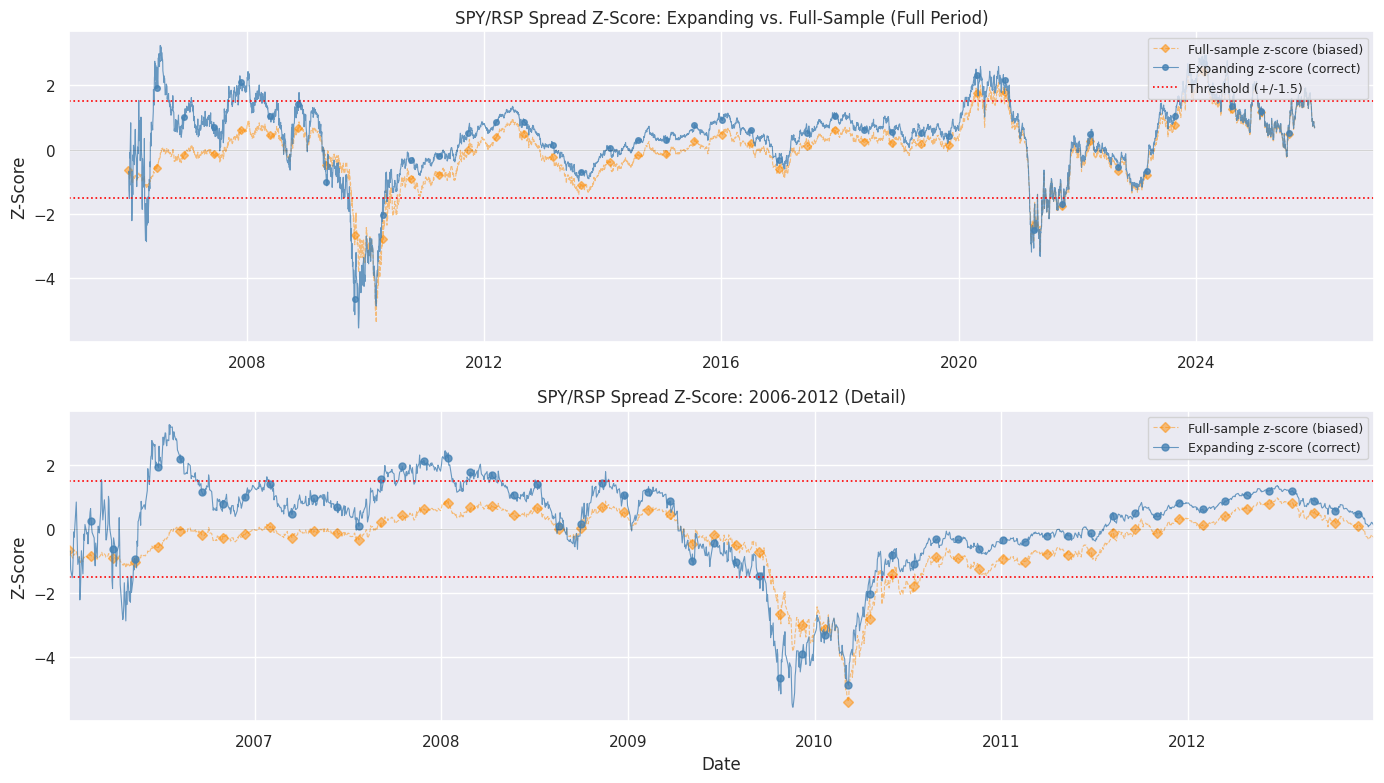

Expanding: long RSP 662 days (13.2%), long SPY 268 days (5.3%), neutral 4099 days (81.5%)
Full-sample: long RSP 345 days (6.9%), long SPY 288 days (5.7%), neutral 4397 days (87.4%)


In [10]:
# ── SPY/RSP z-score comparison chart ──────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax1 = axes[0]

# Biased first so correct sits on top
ax1.plot(df.index, df['Z_Fullsample'],
         color='darkorange', linewidth=0.8, linestyle='dashed', alpha=0.5,
         marker='D', markersize=4, markevery=120,
         label='Full-sample z-score (biased)')

ax1.plot(df.index, df['Z_Expanding'],
         color='steelblue', linewidth=0.8, linestyle='solid', alpha=0.8,
         marker='o', markersize=4, markevery=120,
         label='Expanding z-score (correct)')

ax1.axhline( THRESHOLD, color='red',   linewidth=1.2, linestyle='dotted', label=f'Threshold (+/-{THRESHOLD})')
ax1.axhline(-THRESHOLD, color='red',   linewidth=1.2, linestyle='dotted')
ax1.axhline(0, color='black', linewidth=0.4, linestyle='solid', alpha=0.3)
ax1.set_title('SPY/RSP Spread Z-Score: Expanding vs. Full-Sample (Full Period)')
ax1.set_ylabel('Z-Score')
ax1.legend(loc='upper right', fontsize=9)

# ── Bottom panel: zoom into 2006-2012 ─────────────────────────────────────────
# This period captures the pre-crisis calm, the 2008 crisis, and the recovery.
# The two series should diverge most visibly here because the full-sample
# version already "knows" the post-2017 large cap dominance regime.
ax2 = axes[1]

early_mask = (df.index >= '2006-01-01') & (df.index < '2013-01-01')

ax2.plot(df.index[early_mask], df['Z_Fullsample'][early_mask],
         color='darkorange', linewidth=0.8, linestyle='dashed', alpha=0.5,
         marker='D', markersize=5, markevery=30,
         label='Full-sample z-score (biased)')

ax2.plot(df.index[early_mask], df['Z_Expanding'][early_mask],
         color='steelblue', linewidth=0.8, linestyle='solid', alpha=0.8,
         marker='o', markersize=5, markevery=30,
         label='Expanding z-score (correct)')

ax2.axhline( THRESHOLD, color='red',   linewidth=1.2, linestyle='dotted')
ax2.axhline(-THRESHOLD, color='red',   linewidth=1.2, linestyle='dotted')
ax2.axhline(0, color='black', linewidth=0.4, linestyle='solid', alpha=0.3)
ax2.set_xlim(df.index[early_mask][0], df.index[early_mask][-1])
ax2.set_title('SPY/RSP Spread Z-Score: 2006-2012 (Detail)')
ax2.set_ylabel('Z-Score')
ax2.set_xlabel('Date')
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('fig_10_2_spyrsp_zscore_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Where does the expanding z-score exceed the threshold? ────────────────────
# Shows how often each version was in SPY vs. RSP
for label, z in [('Expanding', df['Z_Expanding']), ('Full-sample', df['Z_Fullsample'])]:
    long_rsp = (z >  THRESHOLD).sum()
    long_spy = (z < -THRESHOLD).sum()
    neutral  = ((z >= -THRESHOLD) & (z <= THRESHOLD)).sum()
    print(f"{label}: long RSP {long_rsp} days ({long_rsp/len(z):.1%}), "
          f"long SPY {long_spy} days ({long_spy/len(z):.1%}), "
          f"neutral {neutral} days ({neutral/len(z):.1%})")

This chart shows what the daily return example could not: the two z-score series tell genuinely different stories about market conditions throughout the sample.

The bottom panel (2006-2012) makes the divergence concrete:

- In 2006-2007, the expanding z-score (blue) was consistently above the +1.5 threshold, signaling that SPY had been unusually strong relative to RSP and generating long RSP positions
- The full-sample z-score (orange) barely approached the threshold in the same period, because it already "knew" that the post-2017 large cap dominance would make 2006-2007 look unremarkable by comparison
- The two series converge more closely after 2015, once the expanding window has accumulated enough history to approach the full-sample statistics

The signal breakdown confirms this:

- Expanding z-score: long RSP on 662 days (13.2%) of the sample
- Full-sample z-score: long RSP on only 345 days (6.9%) of the sample
- Long SPY signals are similar between the two versions (5.3% vs. 5.7%)

The bias is almost entirely on one side. The full-sample version suppressed RSP signals in the early period by using a baseline that reflected future large cap dominance. That is the mechanism behind the performance gap we measured in Section 5.

## Section 7: Summary Comparison Table

The table below consolidates the results from all three experiments in this notebook. It shows the performance impact of the full-sample normalization error across two different series types: stationary (daily log returns) and non-stationary (1-year SPY/RSP spread).

In [11]:
# ── Summary comparison table ───────────────────────────────────────────────────
# Consolidates all results from the notebook into a single reference table.

def compute_metrics_dict(returns, label, simple=False):
    """
    Return a dictionary of performance metrics.
    simple=True: input is simple returns (pct_change style)
    simple=False: input is log returns
    """
    if simple:
        # Convert to log returns for consistent CAGR calculation
        returns = np.log(1 + returns.clip(lower=-0.9999))
    n_years  = len(returns) / 252
    cagr     = np.exp(returns.sum() / n_years) - 1
    sharpe   = (returns.mean() / returns.std()) * np.sqrt(252)
    eq       = np.exp(returns.cumsum())
    drawdown = (eq / eq.cummax() - 1).min()
    win_rate = (returns > 0).sum() / (returns != 0).sum()
    return {
        'Strategy':     label,
        'CAGR':         f"{cagr:.2%}",
        'Sharpe':       f"{sharpe:.2f}",
        'Max Drawdown': f"{drawdown:.2%}",
        'Win Rate':     f"{win_rate:.2%}"
    }

rows = [
    compute_metrics_dict(log_returns,             'SPY Buy-and-Hold'),
    compute_metrics_dict(strat_returns_clean,     'Daily Returns: Expanding z-score (correct)'),
    compute_metrics_dict(strat_returns_biased,    'Daily Returns: Full-sample z-score (biased)'),
    compute_metrics_dict(results_clean['Strategy_Return'],
                         'SPY/RSP Spread: Expanding z-score (correct)',  simple=True),
    compute_metrics_dict(results_biased['Strategy_Return'],
                         'SPY/RSP Spread: Full-sample z-score (biased)', simple=True),
]

df_summary = pd.DataFrame(rows).set_index('Strategy')
print(df_summary.to_string())

                                                CAGR Sharpe Max Drawdown Win Rate
Strategy                                                                         
SPY Buy-and-Hold                              10.70%   0.53      -55.19%   55.33%
Daily Returns: Expanding z-score (correct)    10.71%   0.71      -25.48%   56.53%
Daily Returns: Full-sample z-score (biased)   11.15%   0.73      -27.50%   56.51%
SPY/RSP Spread: Expanding z-score (correct)   10.24%   0.48      -59.92%   54.65%
SPY/RSP Spread: Full-sample z-score (biased)  10.61%   0.52      -55.19%   54.83%


The table brings together all three experiments. A few observations worth noting:

- The daily return strategy reduces max drawdown dramatically (-25.48% vs. -55.19% for buy-and-hold) with nearly identical CAGR. That is the strategy doing its job, not the bias.
- The lookahead bias inflates CAGR by 44 bp in the daily return case and 37 bp in the SPY/RSP case. Neither is enormous in isolation.
- The bias is more visible in the Sharpe and drawdown columns than in CAGR. The biased versions consistently show better risk-adjusted profiles, which is the more insidious distortion: an analyst comparing these strategies would rank the biased version as more robust, not just more profitable.
- The SPY/RSP spread strategies show worse drawdowns than buy-and-hold. This is not a good strategy. It is a teaching vehicle.

The broader point: lookahead bias in normalization does not always produce dramatic results. It produces results that look slightly better than they should across every metric simultaneously. That consistency is what makes it hard to spot without running both versions side by side.

## Section 8: A Simple Code Audit for Normalization Errors

The two examples in this notebook were constructed so we knew exactly where the error was. In practice you will be auditing code you did not write, or code you wrote months ago. The normalization error is easy to miss on a quick read because the syntax is correct: `x.mean()` and `x.std()` are valid pandas operations.

The function below scans a DataFrame for the most common normalization patterns that introduce lookahead bias:

- Full-sample `.mean()` or `.std()` applied directly to a column
- Z-score construction without a rolling or expanding window
- Percentile rank calculations using the full series

It will not catch every possible form of lookahead bias. Think of it as a first-pass checklist, not a guarantee.

In [12]:
def audit_normalization(df: pd.DataFrame, verbose: bool = True) -> list:
    """
    Scan a DataFrame for columns that appear to use full-sample normalization.

    Checks for:
    - Any column whose values match (x - x.mean()) / x.std() pattern
    - Any column whose mean is approximately 0 and std is approximately 1
      (signature of full-sample standardization)
    - Any column whose values match a full-sample percentile rank

    Parameters:
    -----------
    df      : DataFrame to audit
    verbose : print findings if True

    Returns:
    --------
    List of column names flagged as potentially using full-sample normalization.
    """
    flagged = []

    for col in df.select_dtypes(include=[np.number]).columns:
        series = df[col].dropna()

        if len(series) < 30:
            # Too short to assess meaningfully
            continue

        col_mean = series.mean()
        col_std  = series.std()

        # Flag 1: mean near 0 and std near 1
        # This is the signature of full-sample z-score normalization.
        # An expanding z-score will NOT have mean=0, std=1 across the full series.
        if abs(col_mean) < 0.05 and abs(col_std - 1.0) < 0.05:
            flagged.append(col)
            if verbose:
                print(f"[FLAG] '{col}': mean={col_mean:.4f}, std={col_std:.4f}")
                print(f"       Signature of full-sample z-score normalization.")
                print(f"       Check whether an expanding or rolling window should be used.\n")

        # Flag 2: values fall exactly in [0, 1] with mean near 0.5
        # Signature of a full-sample percentile rank (.rank(pct=True))
        elif series.min() >= 0 and series.max() <= 1 and abs(col_mean - 0.5) < 0.05:
            flagged.append(col)
            if verbose:
                print(f"[FLAG] '{col}': values in [0,1], mean={col_mean:.4f}")
                print(f"       Possible full-sample percentile rank.")
                print(f"       Check whether .expanding().rank(pct=True) should be used.\n")

    if not flagged:
        print("No full-sample normalization patterns detected.")
    else:
        print(f"{len(flagged)} column(s) flagged for review: {flagged}")

    return flagged

# ── Run the audit on our working DataFrame ────────────────────────────────────
# We expect Z_Fullsample to be flagged and Z_Expanding to pass.
print("Auditing df columns:\n")
flagged_cols = audit_normalization(df)

Auditing df columns:

[FLAG] 'Z_Fullsample': mean=-0.0000, std=1.0000
       Signature of full-sample z-score normalization.
       Check whether an expanding or rolling window should be used.

1 column(s) flagged for review: ['Z_Fullsample']


The audit function correctly identifies `Z_Fullsample` as a full-sample normalized column and passes `Z_Expanding`.

A few important caveats about this tool:

- It detects the signature of the error (mean near 0, std near 1 across the full series), not the error itself. A column could pass this check and still contain lookahead bias introduced in other ways.
- It will not catch shift errors, resampling leaks, or train/test contamination. Those require reading the code directly.
- It is most useful as a quick first pass when reviewing an unfamiliar pipeline. Any flagged column deserves a closer look at how it was constructed.

The three questions to ask about any normalization step in a backtesting pipeline:

- What data was used to compute the mean and standard deviation?
- Would that data have been available at the time of each historical trade?
- If not, replace with an expanding or rolling window calculation.

*Note that this function is available in functions.py*

## Section 9: Key Takeaways

This notebook demonstrated lookahead bias through a single, common normalization error: using full-sample statistics instead of an expanding window.

Key points:

- The error is syntactically correct and visually invisible in code
- The performance inflation is modest for stationary series (daily log returns) and more material for non-stationary series (SPY/RSP rolling spread)
- The bias is consistent across all metrics simultaneously: CAGR, Sharpe, and drawdown all look slightly better than they should
- The expanding z-score is the only version that reflects what a real-time system would have seen
- The audit function provides a quick first-pass check but does not replace a careful code review

The same error appears in many other forms. Any time you compute a statistic over a full dataset and apply it to historical observations, you are introducing lookahead bias. Common examples:

- **Percentile ranks**: `.rank(pct=True)` on a full series uses future data to determine where each observation falls. Use `.expanding().rank(pct=True)` instead.
- **Machine learning feature standardization**: never fit a scaler on the full dataset. Fit on the training set only, save the transformation parameters, and apply that same transformation to the test set. Fitting separately on train and test, or on the full dataset, leaks future distributional information into the training features.
- **Volatility targeting**: scaling position sizes by realized volatility requires a rolling or expanding volatility estimate. A full-sample estimate compresses positions in calm periods because it already knows the crises are coming.
- **Beta calculations**: rolling beta vs. a benchmark must use only past data. A full-sample beta reflects how a stock behaved in future crises.
- **Hedge ratios in pairs trading**: the OLS regression used to estimate a hedge ratio must be fit on a rolling window. A full-sample fit produces a ratio that is optimal across regimes that had not occurred yet.
- **Winsorization and outlier clipping**: percentile cutoffs for clipping must be computed on an expanding window. Full-sample cutoffs use future extreme events to define what counts as an outlier today.

The general rule: any time a normalization or scaling step appears in a backtesting pipeline, ask whether the parameters used could have been known at the time of each trade. If not, it is lookahead bias regardless of how small the impact appears to be.

There are many other forms of lookahead bias. We have mentioned this so many times in multiple chapters. `.shift()` remains one of the most frequent ways that this bias is introduced. Always do lookahead bias audits throughout all of your code.